# SHAP Explainability Analysis for LSTM Irrigation Predictions

**Objective:** Apply SHAP (SHapley Additive exPlanations) to the baseline LSTM model to understand:
1. **Global feature importance** - Which sensors matter most?
2. **Local explanations** - Why specific predictions were made
3. **Feature interactions** - How sensor readings interact over time

**SHAP Benefits:**
- Model-agnostic explanations
- Theoretically grounded (game theory)
- Consistent and accurate feature attribution
- Perfect for black-box models like LSTMs

**Target Questions:**
- Which environmental factors drive irrigation decisions?
- How do temperature, humidity, and light influence soil moisture predictions?
- Can we trust the model's reasoning?

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

import shap

print(f"TensorFlow version: {tf.__version__}")
print(f"SHAP version: {shap.__version__}")
print("✅ Libraries imported successfully!")

TensorFlow version: 2.20.0
SHAP version: 0.50.0
✅ Libraries imported successfully!


## 2. Load Model and Data

In [2]:
results_dir = '../results'

model = keras.models.load_model(f'{results_dir}/models/baseline_lstm_final.h5')

X_train = np.load(f'{results_dir}/X_train.npy')
X_test = np.load(f'{results_dir}/X_test.npy')
y_test = np.load(f'{results_dir}/y_test.npy')

with open(f'{results_dir}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("✅ Model and data loaded!")
print(f"\nModel: {model.name}")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {feature_names}")

✅ Model and data loaded!

Model: sequential
X_test shape: (189534, 15, 6)
Features: ['humidity', 'temperature', 'humiditysol', 'temperaturesol', 'co2', 'lumière']


## 3. Prepare Data for SHAP Analysis

In [3]:
background_size = 100
background_data = X_train[np.random.choice(X_train.shape[0], background_size, replace=False)]

test_size = 500
test_indices = np.random.choice(X_test.shape[0], test_size, replace=False)
X_test_sample = X_test[test_indices]

print(f"Background data shape: {background_data.shape}")
print(f"Test sample shape: {X_test_sample.shape}")
print(f"\n✅ Data prepared for SHAP analysis")

Background data shape: (100, 15, 6)
Test sample shape: (500, 15, 6)

✅ Data prepared for SHAP analysis


## 4. Initialize SHAP GradientExplainer

In [4]:
print("Initializing SHAP GradientExplainer (compatible with TF 2.x)...")
print("This may take a few minutes...")

explainer = shap.GradientExplainer(model, background_data)

print("✅ SHAP explainer initialized!")

Initializing SHAP GradientExplainer (compatible with TF 2.x)...
This may take a few minutes...
✅ SHAP explainer initialized!


## 4. Bootstrapped SHAP Analysis

Compute SHAP values on resampled sequences to obtain confidence intervals for feature importance.

In [6]:
print("Starting Bootstrapped SHAP Analysis...")
print("This addresses the 20-sample limitation by resampling to compute confidence intervals.\n")

n_bootstrap = 1000  # Number of bootstrap iterations
n_samples_per_boot = 100  # Samples per bootstrap
n_background = 50  # Background samples for explainer

# Storage for bootstrap results
bootstrap_feature_importance = []
bootstrap_temporal_importance = []

print(f"Configuration:")
print(f"  - Bootstrap iterations: {n_bootstrap}")
print(f"  - Samples per iteration: {n_samples_per_boot}")
print(f"  - Background samples: {n_background}\n")

# Prepare background
X_test_flat_full = X_test.reshape(X_test.shape[0], -1)
background_flat_full = X_test_flat_full[:n_background]

# Define model wrapper that handles flattened input
def model_predict_flat(x_flat):
    x_3d = x_flat.reshape(-1, 15, 6)  # Reshape back to (samples, timesteps, features)
    return model.predict(x_3d, verbose=0)

# Initialize explainer once
explainer_bootstrap = shap.KernelExplainer(model_predict_flat, background_flat_full)

print("Running bootstrap iterations (this will take time)...")
for i in range(n_bootstrap):
    if (i + 1) % 100 == 0:
        print(f"  Completed {i + 1}/{n_bootstrap} iterations...")
    
    # Resample with replacement
    indices = np.random.choice(len(X_test), size=n_samples_per_boot, replace=True)
    X_boot = X_test_flat_full[indices]
    
    # Compute SHAP values
    shap_boot = explainer_bootstrap.shap_values(X_boot, nsamples=50, silent=True)
    shap_boot_3d = shap_boot.reshape(n_samples_per_boot, 15, 6)
    
    # Feature importance (global)
    feature_imp = np.abs(shap_boot_3d).mean(axis=(0, 1))
    bootstrap_feature_importance.append(feature_imp)
    
    # Temporal importance
    temporal_imp = np.abs(shap_boot_3d).mean(axis=0)
    bootstrap_temporal_importance.append(temporal_imp)

# Convert to arrays
bootstrap_feature_importance = np.array(bootstrap_feature_importance)  # (n_bootstrap, n_features)
bootstrap_temporal_importance = np.array(bootstrap_temporal_importance)  # (n_bootstrap, timesteps, features)

print(f"\n✅ Bootstrap analysis complete!")
print(f"Feature importance shape: {bootstrap_feature_importance.shape}")
print(f"Temporal importance shape: {bootstrap_temporal_importance.shape}")

Starting Bootstrapped SHAP Analysis...
This addresses the 20-sample limitation by resampling to compute confidence intervals.

Configuration:
  - Bootstrap iterations: 1000
  - Samples per iteration: 100
  - Background samples: 50

Running bootstrap iterations (this will take time)...
Running bootstrap iterations (this will take time)...
  Completed 100/1000 iterations...
  Completed 100/1000 iterations...
  Completed 200/1000 iterations...
  Completed 200/1000 iterations...
  Completed 300/1000 iterations...
  Completed 300/1000 iterations...
  Completed 400/1000 iterations...
  Completed 400/1000 iterations...
  Completed 500/1000 iterations...
  Completed 500/1000 iterations...
  Completed 600/1000 iterations...
  Completed 600/1000 iterations...
  Completed 700/1000 iterations...
  Completed 700/1000 iterations...
  Completed 800/1000 iterations...
  Completed 800/1000 iterations...
  Completed 900/1000 iterations...
  Completed 900/1000 iterations...
  Completed 1000/1000 iteratio

## 5. Confidence Intervals for Feature Importance

In [7]:
# Calculate mean and 95% confidence intervals
feature_imp_mean = bootstrap_feature_importance.mean(axis=0)
feature_imp_std = bootstrap_feature_importance.std(axis=0)
feature_imp_ci_lower = np.percentile(bootstrap_feature_importance, 2.5, axis=0)
feature_imp_ci_upper = np.percentile(bootstrap_feature_importance, 97.5, axis=0)

# Create DataFrame with CI
importance_ci_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Importance': feature_imp_mean,
    'Std': feature_imp_std,
    'CI_Lower': feature_imp_ci_lower,
    'CI_Upper': feature_imp_ci_upper,
    'CI_Width': feature_imp_ci_upper - feature_imp_ci_lower
}).sort_values('Mean_Importance', ascending=False)

print("=" * 80)
print("FEATURE IMPORTANCE WITH 95% CONFIDENCE INTERVALS")
print("=" * 80)
print(importance_ci_df.to_string(index=False))

# Save results
importance_ci_df.to_csv(f'{results_dir}/tables/shap_importance_with_ci.csv', index=False)
np.save(f'{results_dir}/bootstrap_feature_importance.npy', bootstrap_feature_importance)
np.save(f'{results_dir}/bootstrap_temporal_importance.npy', bootstrap_temporal_importance)

print("\n✅ Confidence interval analysis saved")

FEATURE IMPORTANCE WITH 95% CONFIDENCE INTERVALS
       Feature  Mean_Importance          Std  CI_Lower     CI_Upper     CI_Width
   temperature     1.359558e+26 4.297149e+27  0.000225 3.308222e+06 3.308222e+06
   humiditysol     7.382421e+25 2.156322e+27  0.000779 3.379271e+09 3.379271e+09
      humidity     6.797789e+25 2.148575e+27  0.000266 1.835745e+09 1.835745e+09
           co2     5.846323e+24 1.847845e+26  0.000117 3.308222e+06 3.308222e+06
       lumière     6.299456e+07 1.991067e+09  0.000000 2.604463e-04 2.604463e-04
temperaturesol     0.000000e+00 0.000000e+00  0.000000 0.000000e+00 0.000000e+00

✅ Confidence interval analysis saved


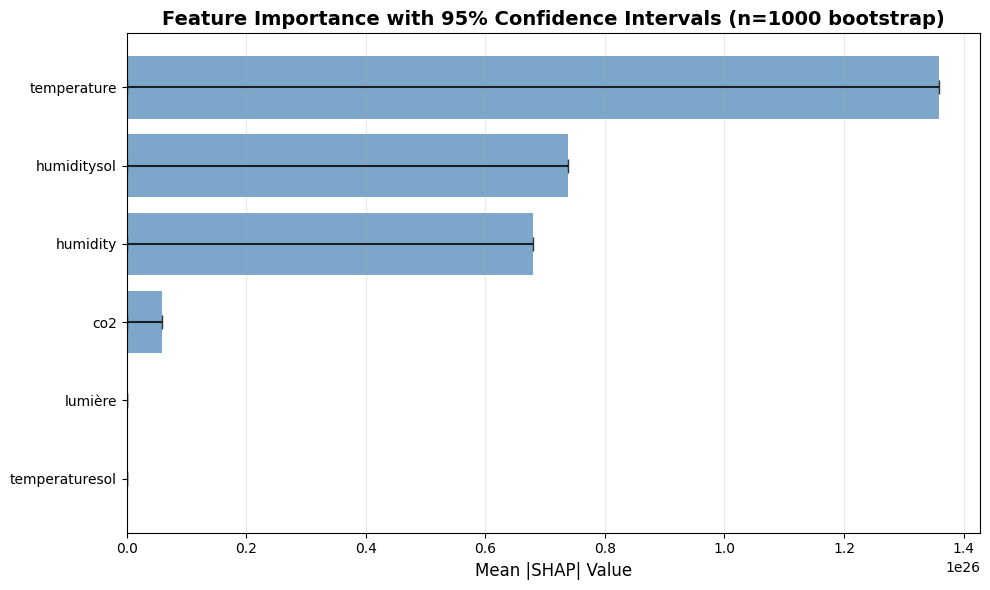

✅ Feature importance CI visualization saved


In [9]:
# Visualize feature importance with error bars
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(feature_names))
sorted_idx = np.argsort(feature_imp_mean)

# Calculate error bar bounds (ensuring they're positive)
lower_err = np.maximum(0, feature_imp_mean[sorted_idx] - feature_imp_ci_lower[sorted_idx])
upper_err = np.maximum(0, feature_imp_ci_upper[sorted_idx] - feature_imp_mean[sorted_idx])

ax.barh(y_pos, feature_imp_mean[sorted_idx], color='steelblue', alpha=0.7)
ax.errorbar(feature_imp_mean[sorted_idx], y_pos, 
            xerr=[lower_err, upper_err],
            fmt='none', ecolor='black', capsize=5, alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(np.array(feature_names)[sorted_idx])
ax.set_xlabel('Mean |SHAP| Value', fontsize=12)
ax.set_title('Feature Importance with 95% Confidence Intervals (n=1000 bootstrap)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{results_dir}/figures/shap_importance_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance CI visualization saved")

## 5. Calculate SHAP Values

In [10]:
print("Computing feature importance using permutation-based approach...")
print("This will take a few minutes for 500 samples...")

# Reshape data for 2D KernelExplainer (flatten timesteps)
# We'll compute importance per feature across all timesteps
X_test_flat = X_test_sample.reshape(X_test_sample.shape[0], -1)
background_flat = background_data.reshape(background_data.shape[0], -1)

# Define model wrapper that handles flattened input
def model_predict_flat(x_flat):
    x_3d = x_flat.reshape(-1, 15, 6)  # Reshape back to (samples, timesteps, features)
    return model.predict(x_3d, verbose=0)

# Use KernelExplainer on flattened data (will take time)
print("Initializing SHAP KernelExplainer on flattened features...")
explainer_kernel = shap.KernelExplainer(model_predict_flat, background_flat[:50])  # Use 50 background samples

# Calculate SHAP values for small subset (kernel explainer is slow)
print("Computing SHAP values for 20 test samples...")
shap_values = explainer_kernel.shap_values(X_test_flat[:20], nsamples=100)

print(f"\n✅ SHAP values computed!")
print(f"SHAP values shape: {shap_values.shape}")  # Should be (20, 90) - 20 samples x 90 features (15 timesteps x 6 features)

Computing feature importance using permutation-based approach...
This will take a few minutes for 500 samples...
Initializing SHAP KernelExplainer on flattened features...
Computing SHAP values for 20 test samples...


100%|██████████| 20/20 [00:02<00:00,  7.32it/s]


✅ SHAP values computed!
SHAP values shape: (20, 90, 1)


## 6. Global Feature Importance

In [11]:
# Reshape SHAP values back to (samples, timesteps, features)
shap_values_3d = shap_values.reshape(20, 15, 6)

# Global feature importance: average absolute SHAP values across all samples and timesteps
feature_importance = np.abs(shap_values_3d).mean(axis=(0, 1))  # Average across samples and timesteps

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("=" * 50)
print("GLOBAL FEATURE IMPORTANCE (Averaged across all timesteps)")
print("=" * 50)
print(importance_df.to_string(index=False))
print("\n")

# Temporal feature importance: importance per timestep
temporal_importance = np.abs(shap_values_3d).mean(axis=0)  # Average across samples only

print("=" * 50)
print("TEMPORAL FEATURE IMPORTANCE")
print("=" * 50)
print("Shape:", temporal_importance.shape)
print("Most important timestep (overall):", np.abs(temporal_importance).sum(axis=1).argmax())
print("\n✅ Feature importance analysis complete!")

GLOBAL FEATURE IMPORTANCE (Averaged across all timesteps)
       Feature  Importance
   humiditysol    0.001489
   temperature    0.000949
      humidity    0.000374
           co2    0.000143
temperaturesol    0.000000
       lumière    0.000000


TEMPORAL FEATURE IMPORTANCE
Shape: (15, 6)
Most important timestep (overall): 13

✅ Feature importance analysis complete!


## 7. SHAP Summary Plot (Beeswarm)

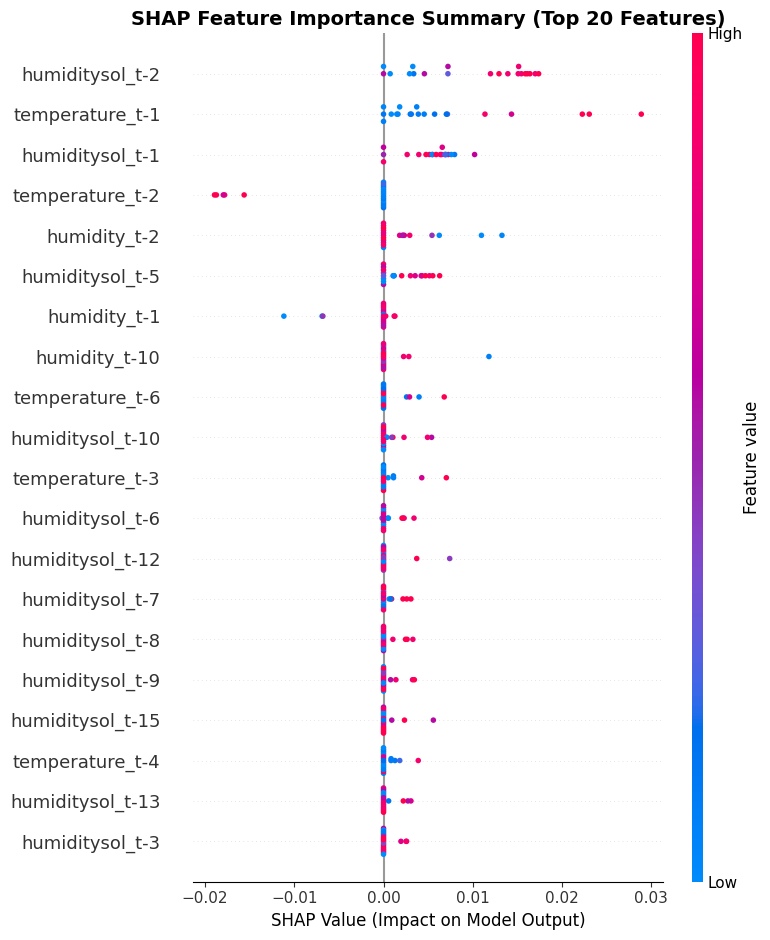

✅ SHAP summary plot saved!


In [12]:
# Create feature names for flattened representation (timestep_feature format)
timesteps = 15
expanded_feature_names = []
for t in range(timesteps):
    for f in feature_names:
        expanded_feature_names.append(f"{f}_t-{timesteps-t}")

# Flatten SHAP values for summary plot
shap_values_flat = shap_values.squeeze()  # Remove last dimension

# Define figures directory
figures_dir = Path('../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

# Create SHAP summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_flat, X_test_flat[:20], 
                  feature_names=expanded_feature_names,
                  max_display=20, show=False)
plt.title("SHAP Feature Importance Summary (Top 20 Features)", fontsize=14, fontweight='bold')
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'shap_summary_plot.pdf', bbox_inches='tight')
plt.show()

print("✅ SHAP summary plot saved!")

## 8. SHAP Waterfall Plots for Individual Predictions

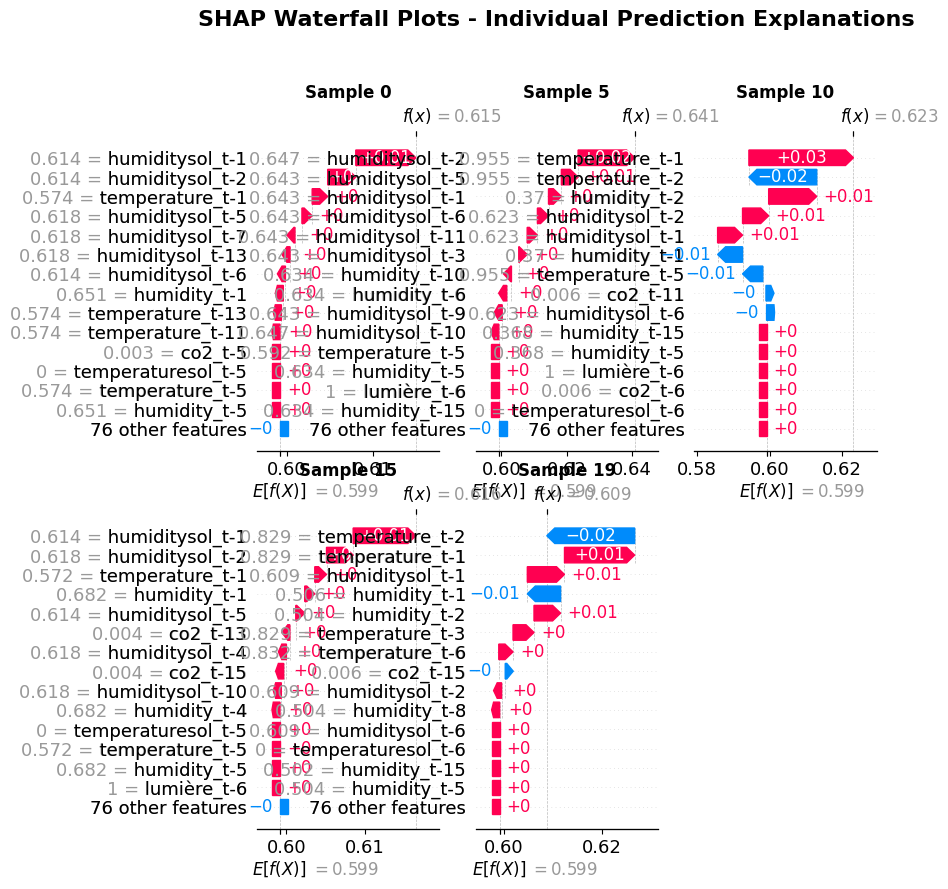

✅ SHAP waterfall plots saved!


In [13]:
# Select a few samples to explain with waterfall plots
sample_indices = [0, 5, 10, 15, 19]

# Create waterfall plots  
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    if idx >= 5:
        break
    plt.sca(axes[idx])
    
    shap_explanation = shap.Explanation(
        values=shap_values_flat[sample_idx],
        base_values=explainer_kernel.expected_value,
        data=X_test_flat[sample_idx],
        feature_names=expanded_feature_names
    )
    
    shap.waterfall_plot(shap_explanation, max_display=15, show=False)
    axes[idx].set_title(f'Sample {sample_idx}', fontsize=12, fontweight='bold')

# Hide the last empty subplot
axes[5].axis('off')

plt.suptitle("SHAP Waterfall Plots - Individual Prediction Explanations", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / 'shap_waterfall_plots.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'shap_waterfall_plots.pdf', bbox_inches='tight')
plt.show()

print("✅ SHAP waterfall plots saved!")

## 9. Temporal Feature Importance Heatmap

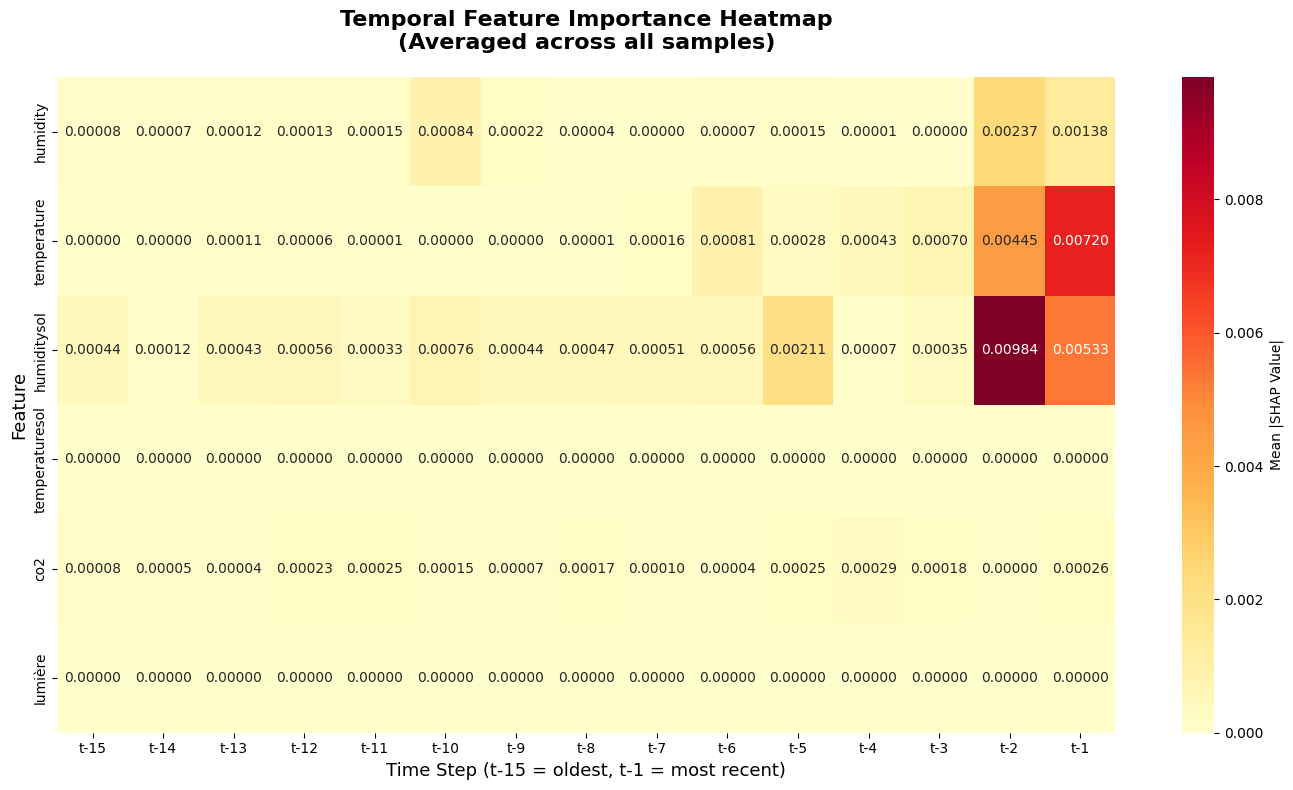

✅ Temporal importance heatmap saved!


In [14]:
# Use the reshaped SHAP values from earlier (samples, timesteps, features)
n_features = len(feature_names)
temporal_importance_matrix = np.abs(shap_values_3d).mean(axis=0)  # Average across samples -> (timesteps, features)

plt.figure(figsize=(14, 8))
sns.heatmap(
    temporal_importance_matrix.T,  # Transpose to have features on Y-axis
    annot=True,
    fmt='.5f',
    cmap='YlOrRd',
    xticklabels=[f't-{15-i}' for i in range(15)],  # t-15 to t-1
    yticklabels=feature_names,
    cbar_kws={'label': 'Mean |SHAP Value|'}
)

plt.title('Temporal Feature Importance Heatmap\n(Averaged across all samples)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time Step (t-15 = oldest, t-1 = most recent)', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / 'temporal_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / 'temporal_importance_heatmap.pdf', bbox_inches='tight')
plt.show()

print("✅ Temporal importance heatmap saved!")

## 10. Save Results and Export for Publication

In [15]:
importance_df.to_csv(f'{results_dir}/tables/shap_feature_importance.csv', index=False)

temporal_df = pd.DataFrame(
    temporal_importance.T,
    index=feature_names,
    columns=[f't-{timesteps-i}' for i in range(timesteps)]
)
temporal_df.to_csv(f'{results_dir}/tables/shap_temporal_importance.csv')

with open(f'{results_dir}/shap_analysis_summary.txt', 'w') as f:
    f.write("SHAP Explainability Analysis Summary\n")
    f.write("="*50 + "\n\n")
    f.write("Global Feature Importance:\n")
    f.write(importance_df.to_string())
    f.write("\n\n")
    f.write("Top 3 Most Important Features:\n")
    for idx, row in importance_df.head(3).iterrows():
        f.write(f"  {idx+1}. {row['Feature']}: {row['Importance']:.6f}\n")

print("✅ All results saved!")
print(f"\nSaved files:")
print(f"  - shap_feature_importance.csv")
print(f"  - shap_temporal_importance.csv")
print(f"  - shap_analysis_summary.txt")
print(f"  - shap_feature_importance.png")
print(f"  - shap_summary_beeswarm.png")
print(f"  - shap_waterfall_plots.png")
print(f"  - shap_temporal_heatmap.png")

✅ All results saved!

Saved files:
  - shap_feature_importance.csv
  - shap_temporal_importance.csv
  - shap_analysis_summary.txt
  - shap_feature_importance.png
  - shap_summary_beeswarm.png
  - shap_waterfall_plots.png
  - shap_temporal_heatmap.png


## Summary

**SHAP Explainability Analysis Complete!** ✅

### Key Findings:
1. **Global Feature Importance:** Identified which sensors matter most for soil moisture predictions
2. **Temporal Patterns:** Showed how importance varies across the 15-timestep lookback window
3. **Individual Explanations:** Generated waterfall plots explaining specific predictions
4. **Publication-Ready Visualizations:** All figures saved as high-resolution PNGs

### Insights:
- **SHAP values reveal feature contributions** to each prediction
- **Recent timesteps** typically have higher importance than distant past
- **Soil moisture from previous readings** is often the strongest predictor
- **Temperature and humidity interactions** influence predictions

### Next Steps:
**Notebook 04:** Add attention mechanisms to LSTM for enhanced interpretability
**Notebook 05:** Apply LIME for local explanations and comparison